In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import kagglehub

# Download latest version
path = kagglehub.dataset_download("brandao/diabetes")

print("Path to dataset files:", path)

Path to dataset files: /Users/tonyianniello/.cache/kagglehub/datasets/brandao/diabetes/versions/1


In [58]:
df = pd.read_csv(f"{path}/diabetic_data.csv")
df.shape

(101766, 50)

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [60]:
print('Percentage of null weight values:', round(df[df['weight'] == '?']['weight'].count() /
    df.shape[0] * 100, 2)
)

print('Percentage of null race values:', round(df[df['race'] == '?']['race'].count() /
      df.shape[0] * 100, 2)
)

Percentage of null weight values: 96.86
Percentage of null race values: 2.23


In [61]:
# missing values, max_glu_serum and A1Cresult were not tested
# on those patients, not data entry error
df.isna().sum().sort_values(ascending=False)

max_glu_serum               96420
A1Cresult                   84748
encounter_id                    0
nateglinide                     0
glimepiride                     0
acetohexamide                   0
glipizide                       0
glyburide                       0
tolbutamide                     0
pioglitazone                    0
rosiglitazone                   0
acarbose                        0
miglitol                        0
troglitazone                    0
tolazamide                      0
examide                         0
citoglipton                     0
insulin                         0
glyburide-metformin             0
glipizide-metformin             0
glimepiride-pioglitazone        0
metformin-rosiglitazone         0
metformin-pioglitazone          0
change                          0
diabetesMed                     0
chlorpropamide                  0
repaglinide                     0
patient_nbr                     0
medical_specialty               0
race          

In [62]:
# instead of NA, we have '?' for missing values
# i can drop weight - other categories missing values have enough
(
    (df[df == '?'].count().sort_values(ascending=False) * 100) /
    df.shape[0]
)

weight                      96.858479
medical_specialty           49.082208
payer_code                  39.557416
race                         2.233555
diag_3                       1.398306
diag_2                       0.351787
diag_1                       0.020636
encounter_id                 0.000000
tolazamide                   0.000000
glyburide                    0.000000
tolbutamide                  0.000000
pioglitazone                 0.000000
rosiglitazone                0.000000
acarbose                     0.000000
miglitol                     0.000000
troglitazone                 0.000000
citoglipton                  0.000000
examide                      0.000000
acetohexamide                0.000000
insulin                      0.000000
glyburide-metformin          0.000000
glipizide-metformin          0.000000
glimepiride-pioglitazone     0.000000
metformin-rosiglitazone      0.000000
metformin-pioglitazone       0.000000
change                       0.000000
diabetesMed 

In [63]:
df = df.drop(columns=['weight'])

In [ ]:
# histograms of numeric features
df.drop(columns = ['encounter_id','patient_nbr']).hist(figsize=(20, 15), bins = 50)
plt.tight_layout()
plt.show()

In [ ]:
# number of patients readmitted vs not readmitted
df['readmitted'].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

,num_lab_procedures,num_procedures,num_medications,time_in_hospital
readmitted,,,,
<30,44.226028,1.280884,16.903143,4.768249
>30,43.836601,1.249599,16.282768,4.495541
NO,42.381598,1.410305,15.670367,4.254429


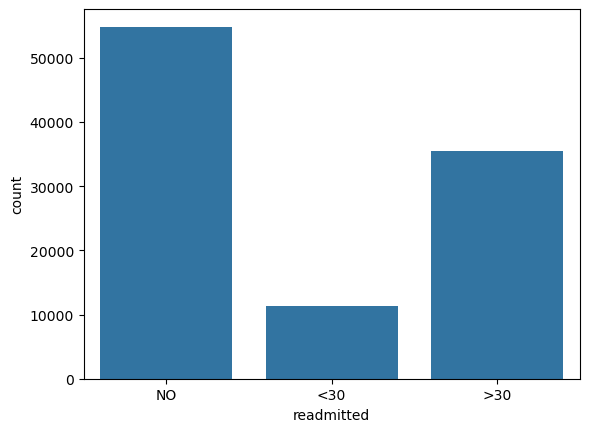

In [ ]:
# check for class imbalance
sns.countplot(data = df,
              x = 'readmitted',
              order = ['NO', '<30', '>30'])
df.groupby(by = 'readmitted').agg({'num_lab_procedures': 'mean',
                                   'num_procedures': 'mean',
                                   'num_medications': 'mean',
                                   'time_in_hospital': 'mean'})

<Axes: xlabel='readmitted', ylabel='proportion'>

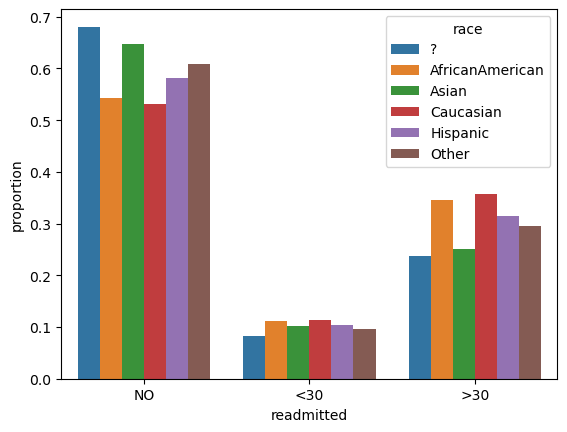

In [ ]:
# readmission rates by race
prop_df = (
    df.groupby(by = ['race', 'readmitted'])
    .size()
    .reset_index(name='count')
)
prop_df['proportion'] = prop_df.groupby('race')['count'].transform(lambda x: x / x.sum())

# barplot of results
sns.barplot(data = prop_df,
            x = 'readmitted',
            y = 'proportion',
            hue = 'race',
            order = ['NO', '<30', '>30'])

<Axes: xlabel='readmitted', ylabel='proportion'>

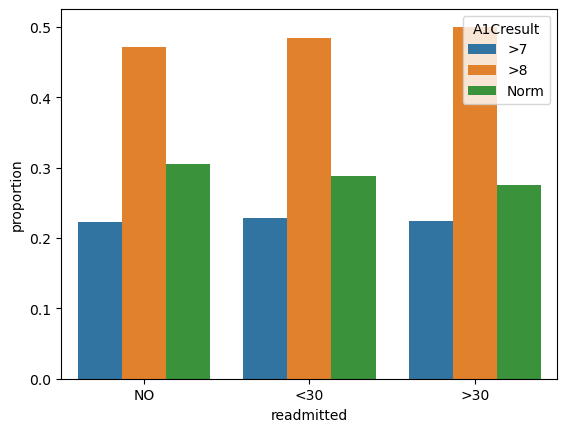

In [ ]:
# A1c results by readmission status
A1C_df = (df.groupby(by = ['A1Cresult', 'readmitted'])
     .size()
     .reset_index(name='count')
)
A1C_df['proportion'] = A1C_df.groupby('readmitted')['count'].transform(lambda x: x / x.sum())

sns.barplot(data = A1C_df,
            x = 'readmitted',
            y = 'proportion',
            hue = 'A1Cresult',
            errorbar = 'se',
            order = ['NO', '<30', '>30'])

<Axes: xlabel='readmitted', ylabel='proportion'>

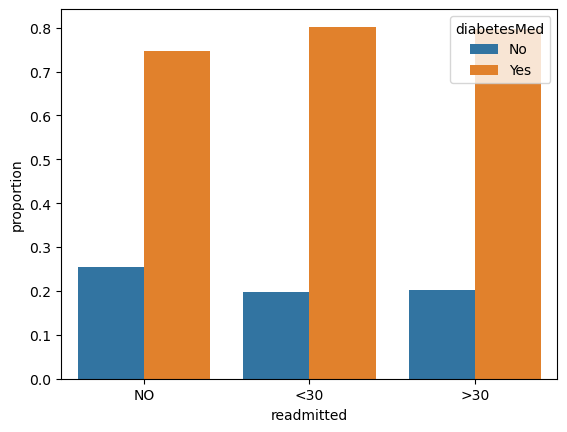

In [ ]:
# diabetes medications by readmission status
diabet_df = (df.groupby(by = ['diabetesMed', 'readmitted'])
     .size()
     .reset_index(name='count')
)
diabet_df['proportion'] = diabet_df.groupby('readmitted')['count'].transform(lambda x: x / x.sum())


sns.barplot(data = diabet_df,
            x = 'readmitted',
            y = 'proportion',
            hue = 'diabetesMed',
            order = ['NO', '<30', '>30'])

<Axes: xlabel='readmitted', ylabel='proportion'>

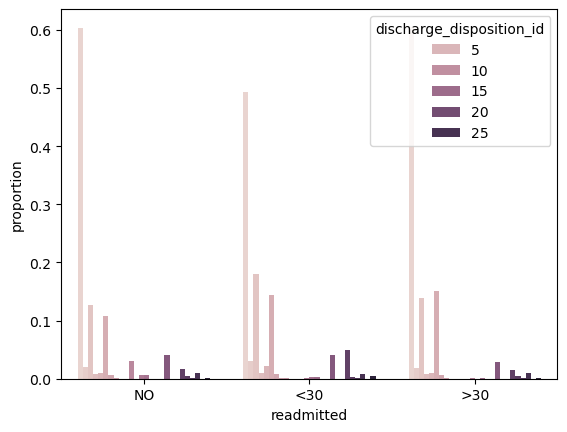

In [ ]:
# discharge disposition by readmission status
discharge_df = (df.groupby(by = ['discharge_disposition_id', 'readmitted'])
     .size()
     .reset_index(name='count')
)
discharge_df['proportion'] = discharge_df.groupby('readmitted')['count'].transform(lambda x: x / x.sum())
sns.barplot(data = discharge_df,
            x = 'readmitted',
            y = 'proportion',
            hue = 'discharge_disposition_id',
            errorbar = 'se',
            order = ['NO', '<30', '>30'])

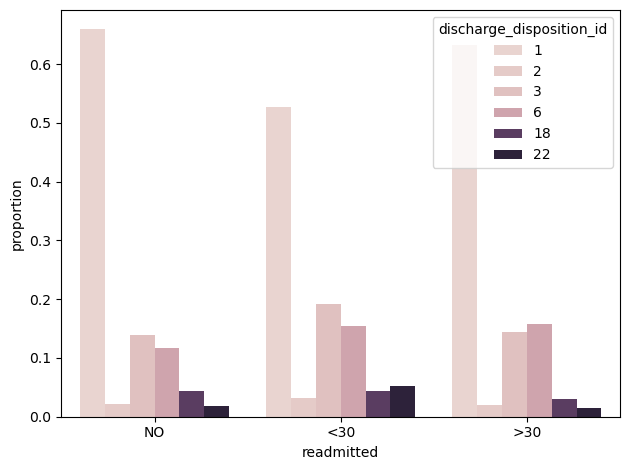

In [ ]:
top_dispositions = df['discharge_disposition_id'].value_counts().head(6).index
df_filtered = df[df['discharge_disposition_id'].isin(top_dispositions)]

discharge_df = (df_filtered.groupby(by = ['discharge_disposition_id', 'readmitted'])
     .size()
     .reset_index(name='count')
)
discharge_df['proportion'] = discharge_df.groupby('readmitted')['count'].transform(lambda x: x / x.sum())
sns.barplot(data = discharge_df,
            x = 'readmitted',
            y = 'proportion',
            hue = 'discharge_disposition_id',
            errorbar = 'se',
            order = ['NO', '<30', '>30'])
plt.tight_layout()

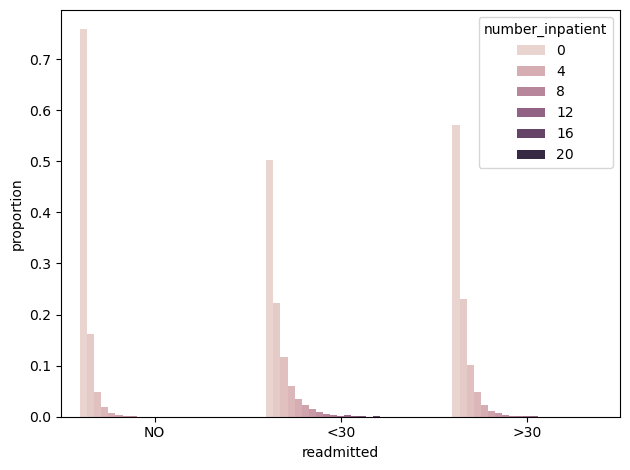

In [ ]:
# prior inpatient visits by readmission status
prior_inpatient_df = (df.groupby(by = ['number_inpatient', 'readmitted'])
     .size()
     .reset_index(name='count')
)
prior_inpatient_df['proportion'] = prior_inpatient_df.groupby('readmitted')['count'].transform(lambda x: x / x.sum())
sns.barplot(data = prior_inpatient_df,
            x = 'readmitted',
            y = 'proportion',
            hue = 'number_inpatient',
            errorbar = 'se',
            order = ['NO', '<30', '>30'])
plt.tight_layout()

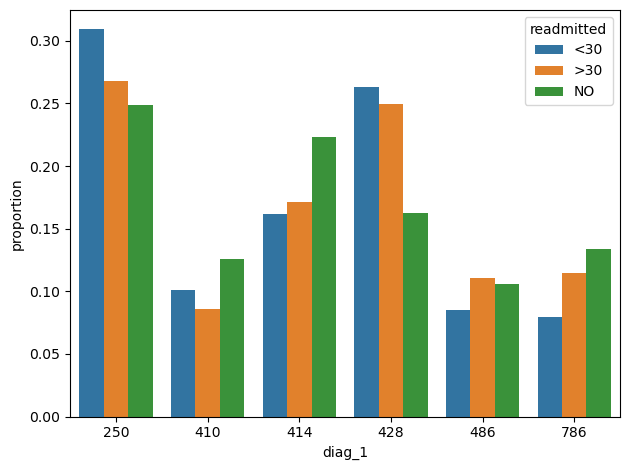

In [ ]:
top_diagnoses = df['diag_1'].value_counts().head(6).index
df_filtered = df[df['diag_1'].isin(top_diagnoses)]
diagnosis_df = (df_filtered.groupby(by = ['diag_1', 'readmitted'])
     .size()
     .reset_index(name='count')
)
diagnosis_df['proportion'] = diagnosis_df.groupby('readmitted')['count'].transform(lambda x: x / x.sum())
sns.barplot(data = diagnosis_df,
            x = 'diag_1',
            y = 'proportion',
            hue = 'readmitted',
            errorbar = 'se')
plt.tight_layout()


In [ ]:
# primary diagnosis of ICD-9 code 250 is miswritten as 250.00, 250.01, etc. 
# I want to check how many patients have diabetes as primary diagnosis
x = 0
for diag in df['diag_1']:
    if '.' in diag:
        if diag.partition('.')[0] == '250':
            x += 1
print (x)

# fix diabetes code for primary, secondary, and tertiary diagnoses
df['diag_1'] = [diag.partition('.')[0] for diag in df['diag_1']]
df['diag_2'] = [diag.partition('.')[0] for diag in df['diag_2']]
df['diag_3'] = [diag.partition('.')[0] for diag in df['diag_3']]

8522


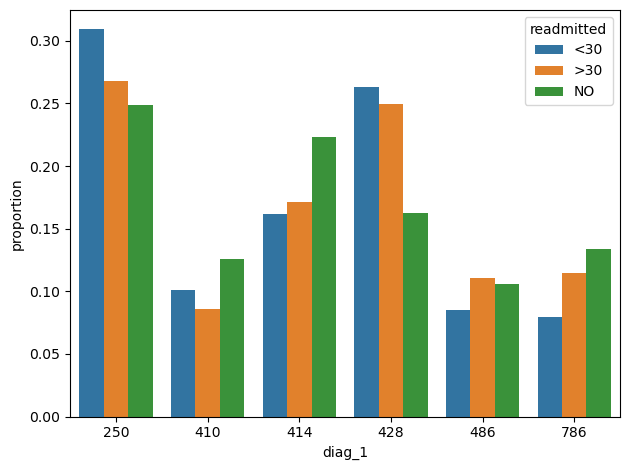

In [ ]:
# re-run diagnosis by readmission status with fixed diabetes codes
top_diagnoses = df['diag_1'].value_counts().head(6).index
df_filtered = df[df['diag_1'].isin(top_diagnoses)]
diagnosis_df = (df_filtered.groupby(by = ['diag_1', 'readmitted'])
     .size()
     .reset_index(name='count')
)
diagnosis_df['proportion'] = diagnosis_df.groupby('readmitted')['count'].transform(lambda x: x / x.sum())
sns.barplot(data = diagnosis_df,
            x = 'diag_1',
            y = 'proportion',
            hue = 'readmitted',
            errorbar = 'se')
plt.tight_layout()